Pip install statements

In [77]:
#pip install statements
#pip install pandas
#pip install scipy
#pip install xgboost
#pip install scikit-learn
#pip install imblearn
#pip install optuna
#pip install hyperopt

Loading in Data and Feature Engineering

In [78]:
import pandas as pd
file_path = "diabetic_data.csv"
df_diabetic = pd.read_csv(file_path)
display(df_diabetic)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [79]:
df_diabetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [80]:
df_diabetic.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [81]:
print(df_diabetic.isna().sum())
#patient_nbr is primary key, race, gender, age, and weight could be something
#max_glu_serum and A1Cresult are null in cases where the medical test wasn't
#performed
#payer_code could be interesting as it seems to be an indication of medical insurance, time_in_hospital could be interesting
#number_outpatient, number_inpatient, and number_emergency could be combined
#for total number of visits of the patient in the year preceding the encounter
#the rest of the features, specifically the second half of the features, are for medications, as in if they were prescribed and what the dosage was
#number_diagnoses could be something, but I'm not too sure


encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [82]:
#Make new variables here
df_diabetic['number_visits'] = df_diabetic['number_outpatient'].astype(int) + df_diabetic['number_emergency'].astype(int) + df_diabetic['number_inpatient'].astype(int)
print(df_diabetic.isna().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [83]:
#Take care of null values
df_diabetic['max_glu_serum'] = df_diabetic['max_glu_serum'].fillna('None')
df_diabetic['A1Cresult'] = df_diabetic['A1Cresult'].fillna('None')

In [84]:
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
#Link for getting all p values: https://www.statology.org/p-value-correlation-pandas/
df_diabetic_categorical = df_diabetic.drop(['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency', 'number_diagnoses', 'number_visits'], axis=1)
for c in df_diabetic_categorical.columns:
    df_diabetic_categorical[c] = df_diabetic_categorical[c].astype('category')

df_diabetic_numerical = df_diabetic[['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency', 'number_diagnoses', 'number_visits']]
#print(pearsonr(df_diabetic_numerical['encounter_id'], df_diabetic_numerical['patient_nbr']))

def r_pvalues_final(df):
    for r in df.columns:
        for c in df.columns:
            print(r, c)
            print(pearsonr(df[r], df[c])[1])
print(r_pvalues_final(df_diabetic_numerical))
#Number_Visits with discharge_disposition_id
#number_emergency, num_lab_procedures
#number_outpatient, num_lab_procedures
#number_outpatient, discharge_disposition_id
#num_lab_procedures, number_emergency
#discharge_disposition_id, number_visits


encounter_id encounter_id
0.0
encounter_id patient_nbr
0.0
encounter_id admission_type_id
0.0
encounter_id discharge_disposition_id
0.0
encounter_id admission_source_id
2.404295582874098e-283
encounter_id time_in_hospital
7.72035825375896e-88
encounter_id num_lab_procedures
9.144374062909191e-17
encounter_id num_procedures
5.678869291325687e-06
encounter_id num_medications
1.3374841138635192e-130
encounter_id number_outpatient
1.5991273836686323e-241
encounter_id number_inpatient
5.1161612578480053e-23
encounter_id number_emergency
2.8166231463762986e-154
encounter_id number_diagnoses
0.0
encounter_id number_visits
7.049447548480134e-262
patient_nbr encounter_id
0.0
patient_nbr patient_nbr
0.0
patient_nbr admission_type_id
0.0003851922369790736
patient_nbr discharge_disposition_id
0.0
patient_nbr admission_source_id
2.6905482167546028e-25
patient_nbr time_in_hospital
1.5107700620114175e-14
patient_nbr num_lab_procedures
3.63277872333086e-07
patient_nbr num_procedures
6.792168633666561e

In [85]:
#Reference link
def r_chisquarevalues(df):
    for r in df.columns:
        for c in df.columns:
            print(r, c)
            frequency_table = pd.crosstab(df[r], df[c])
            result = chi2_contingency(frequency_table)
            print(result.pvalue)
print(r_chisquarevalues(df_diabetic_categorical))
#race max_glu_serum
#race chlorporpamide
#race acetohexamide
#race tolbutamide
#race miglitol
#race troglitazone
#race tolazamide
#race examide
#race citoglipton
#race glipizide-metformin
#race glimepiride-pioglitazone
#race metformin-pioglitazone
#gender max_glu_serum
#gender metformin
#I'm looking through these values and honestly I think most, if not all of the medications should be taken out honestly.

race race
0.0
race gender
7.338989951651933e-122
race age
0.0
race weight
1.1126508093704084e-116
race payer_code
0.0
race medical_specialty
0.0
race diag_1
0.0
race diag_2
0.0
race diag_3
4.655231459541626e-206
race max_glu_serum
4.9676184249830806e-98
race A1Cresult
3.886412294555034e-62
race metformin
4.2182509083426894e-07
race repaglinide
2.1442943742477521e-13
race nateglinide
4.199652519161295e-05
race chlorpropamide
0.30797618052020426
race glimepiride
2.2720231550391057e-10
race acetohexamide
0.9968824218828245
race glipizide
1.2623776107645887e-09
race glyburide
5.5783466209875326e-15
race tolbutamide
0.43836869357324815
race pioglitazone
3.645992278588897e-12
race rosiglitazone
0.03739780504642925
race acarbose
0.008029810926867952
race miglitol
0.9877161162829561
race troglitazone
0.9616016593628274
race tolazamide
0.9816906497124422
race examide
1.0
race citoglipton
1.0
race insulin
1.5024785208857034e-109
race glyburide-metformin
3.6469363828952504e-18
race glipizide-metf

In [86]:
#Drop any columns here, then concatenate the two dataframes together

df_diabetic_final_features = pd.concat([df_diabetic_numerical, df_diabetic_categorical], axis=1)

In [87]:
print(df_diabetic_final_features.columns)

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_inpatient', 'number_emergency',
       'number_diagnoses', 'number_visits', 'race', 'gender', 'age', 'weight',
       'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [88]:
print(df_diabetic_final_features['readmitted'].unique())

['NO', '>30', '<30']
Categories (3, object): ['<30', '>30', 'NO']


In [89]:
print(df_diabetic_final_features['acarbose'].unique())

['No', 'Steady', 'Up', 'Down']
Categories (4, object): ['Down', 'No', 'Steady', 'Up']


In [90]:
print(df_diabetic_final_features.isnull().sum())

encounter_id                0
patient_nbr                 0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_inpatient            0
number_emergency            0
number_diagnoses            0
number_visits               0
race                        0
gender                      0
age                         0
weight                      0
payer_code                  0
medical_specialty           0
diag_1                      0
diag_2                      0
diag_3                      0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamid

In [91]:
df_diabetic_final_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   admission_type_id         101766 non-null  int64   
 3   discharge_disposition_id  101766 non-null  int64   
 4   admission_source_id       101766 non-null  int64   
 5   time_in_hospital          101766 non-null  int64   
 6   num_lab_procedures        101766 non-null  int64   
 7   num_procedures            101766 non-null  int64   
 8   num_medications           101766 non-null  int64   
 9   number_outpatient         101766 non-null  int64   
 10  number_inpatient          101766 non-null  int64   
 11  number_emergency          101766 non-null  int64   
 12  number_diagnoses          101766 non-null  int64   
 13  number_visits             101

Resampling The Data Using Various Methods

In [92]:
import xgboost as xgb
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
#Reference for using eval_metric of aucpr: https://xgboost.readthedocs.io/en/stable/parameter.html

X = df_diabetic_final_features.drop(['readmitted'], axis=1)
y = df_diabetic_final_features['readmitted']
y = y.map({'NO':0, '<30':1, '>30':2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Enable categorical needs to be set to true, otherwise an error occurs
xgb_model = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict_proba(X_test)

base_aucpr = average_precision_score(y_test, y_pred)
print(base_aucpr)

0.46986067232352563


In [93]:
#SMOTENC
from imblearn.over_sampling import SMOTENC
#Just as a heads up this cell takes about two minutes to run
smotenc = SMOTENC(categorical_features=[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], random_state=42)

X_res, y_res = smotenc.fit_resample(X, y)

xgb_model_smotenc = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)

X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

xgb_model_smotenc.fit(X_train_res, y_train_res)

y_pred_smotenc = xgb_model.predict_proba(X_test_res)

smotenc_aucpr = average_precision_score(y_test_res, y_pred_smotenc)
print(smotenc_aucpr)

0.6839474692129855


In [94]:
#For the rest of the SMOTE methods, all categorical columns
#must be mapped to numerical features
df_diabetic_final_features_numerical_only = df_diabetic_final_features.copy()

for c in df_diabetic_final_features_numerical_only.columns:
    if df_diabetic_final_features_numerical_only[c].dtype == 'category':
        list_of_unique_values = df_diabetic_final_features_numerical_only[c].unique()
        map_input = {j:i for i,j in enumerate(list_of_unique_values)}
        df_diabetic_final_features_numerical_only[c] = df_diabetic_final_features_numerical_only[c].map(map_input)

#Test to make sure this works
print(df_diabetic_final_features_numerical_only['readmitted'].unique())


[0, 1, 2]
Categories (3, int64): [2, 1, 0]


In [95]:
X_numerical = df_diabetic_final_features_numerical_only.drop(['readmitted'], axis=1)
y_numerical = df_diabetic_final_features_numerical_only['readmitted']

X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_numerical, y_numerical, test_size=0.2, random_state=42)


In [96]:
#Reference Link for why only the training data is resampled: https://datascience.stackexchange.com/questions/57882/resampling-for-imbalaced-datasets-should-testing-set-also-be-resampled

In [97]:
#SMOTENN
#Reference link: https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTEENN.html

#It takes 4 minutes to run but it works

from imblearn.combine import SMOTEENN
sme = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = sme.fit_resample(X_train_res, y_train_res)

xgb_model_sme = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)

xgb_model_sme.fit(X_train_sme, y_train_sme)

y_pred_SMOTEENN = xgb_model_sme.predict_proba(X_test_res)

SMOTEENN_aucpr = average_precision_score(y_test_res, y_pred_SMOTEENN)
print(SMOTEENN_aucpr)

KeyboardInterrupt: 

In [ ]:
#BorderlineSMOTE

#This also takes 4 minutes to run. I have no idea why BorderlineSmote and SMOTEENN have the same aucpr
from imblearn.over_sampling import BorderlineSMOTE
bsmote = BorderlineSMOTE(random_state=42)
X_train_bsmote, y_train_bsmote = sme.fit_resample(X_train_res, y_train_res)

xgb_model_bsmote = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)

xgb_model_bsmote.fit(X_train_bsmote, y_train_bsmote)

y_pred_BORDERLINESMOTE = xgb_model_bsmote.predict_proba(X_test_res)

BORDERLINESMOTE_aucpr = average_precision_score(y_test_res, y_pred_BORDERLINESMOTE)
print(BORDERLINESMOTE_aucpr)


In [ ]:
#SVMSMOTE
from imblearn.over_sampling import SVMSMOTE
#This cell has been running for over 6 hours and is still going,
#Running this cell in google colab might be a good idea if anyone knows
#how to set that up
#SVMSmote taking a while is normal according to the research I did, but I
#don't know if it is supposed to take this long. Either way I'm not sure if this
#method in particular is viable
svm = SVMSMOTE(random_state=42)
X_train_svm, y_train_svm = svm.fit_resample(X_train_res, y_train_res)

xgb_model_svm = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)

xgb_model_svm.fit(X_train_svm, y_train_svm)

y_pred_SVMSMOTE = xgb_model_svm.predict_proba(X_test_res)

SVMSMOTE_aucpr = average_precision_score(y_test_res, y_pred_SVMSMOTE)
print(SVMSMOTE_aucpr)

In [ ]:
#KMeansSMOTE
from imblearn.over_sampling import KMeansSMOTE
ksm = KMeansSMOTE(random_state=42)
X_train_ksm, y_train_ksm = ksm.fit_resample(X_train_res, y_train_res)

xgb_model_ksm = xgb.XGBClassifier(eval_metric='aucpr', enable_categorical=True)

xgb_model_ksm.fit(X_train_ksm, y_train_ksm)

y_pred_KMEANSSMOTE = xgb_model_ksm.predict_proba(X_test_res)

KMEANSSMOTE_aucpr = average_precision_score(y_test_res, y_pred_KMEANSSMOTE)
print(KMEANSSMOTE_aucpr)

Finetuning XGBoost

In [ ]:

# Redefining from earlier
X = df_diabetic_final_features.drop(['readmitted'], axis=1)
y = df_diabetic_final_features['readmitted'].map({'NO': 0, '<30': 1, '>30': 2})

# First split into temp and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Then split temp into train and valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# Confirming the shapes and data types of the splits. Should be 60% train, 20% valid, 20% test
# We should omit this before submission
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)
print(X_train.dtypes.value_counts())

X_train shape: (61059, 50)
X_valid shape: (20353, 50)
X_test shape: (20354, 50)
int64       14
category    13
category     7
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [111]:
import optuna
from xgboost import XGBClassifier

# Optuna is based on defining an objective function that takes a trial object as input, which is used to suggest hyperparameters.
# The function then trains a model using those hyperparameters and evaluates its performance, 
# returning a metric that Optuna will try to maximize or minimize.

# The definition of object here is the standard way to define an objective function for Optuna. 
# The trial object is used to suggest values for the hyperparameters of the XGBClassifier.
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "tree_method": "hist",
        "enable_categorical": True
    }

    model = XGBClassifier(**params, early_stopping_rounds=30)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_valid_prediction = model.predict(X_valid)
    return f1_score(y_valid, y_valid_prediction, average="macro")

# A study in Optuna is an optimization session that manages the trials and their results.
# We create a study object and specify that we want to maximize the macro F1 score.
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# We then use study parameters to get the best trial and its value, which is the best macro F1 score achieved during the optimization process.
print("Best Macro F1:", study.best_trial.value)
print("Best Params:")

for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")

[I 2026-03-31 11:28:45,115] A new study created in memory with name: no-name-7d2dedeb-0687-434a-a283-ef4992601344
[I 2026-03-31 11:28:56,068] Trial 0 finished with value: 0.3332084937087743 and parameters: {'n_estimators': 436, 'max_depth': 8, 'learning_rate': 0.0017994118917811738, 'subsample': 0.9353464964914838, 'colsample_bytree': 0.8198916814921169, 'min_child_weight': 8, 'gamma': 3.3249699682718137, 'reg_alpha': 0.04178733289020955, 'reg_lambda': 7.042877646209591e-07}. Best is trial 0 with value: 0.3332084937087743.
[I 2026-03-31 11:28:58,012] Trial 1 finished with value: 0.4105795309194715 and parameters: {'n_estimators': 225, 'max_depth': 6, 'learning_rate': 0.06105395113945516, 'subsample': 0.7388487115774969, 'colsample_bytree': 0.9767740856083683, 'min_child_weight': 2, 'gamma': 0.24387780970337058, 'reg_alpha': 4.211119594433188e-07, 'reg_lambda': 0.26525189580117703}. Best is trial 1 with value: 0.4105795309194715.
[I 2026-03-31 11:29:08,005] Trial 2 finished with value: 

Best Macro F1: 0.44944768610401936
Best Params:
n_estimators: 320
max_depth: 6
learning_rate: 0.15419077469642012
subsample: 0.9932160703040938
colsample_bytree: 0.6216126358556351
min_child_weight: 6
gamma: 0.05206716478082839
reg_alpha: 7.749050242765449
reg_lambda: 0.015090041513586096


In [ ]:
# Now we use the best hyperparameters to train the final model on the combined training and validation set, and evaluate on the test set.

# Parameters gotten from Optuna, with some additional parameters added in that are necessary for the model. 
optuna_params = study.best_trial.params.copy()
optuna_params.update({
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "random_state": 42,
    "tree_method": "hist",
    "enable_categorical": True
})

optuna_model = XGBClassifier(**optuna_params, early_stopping_rounds=30)

optuna_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

y_test_prediction = optuna_model.predict(X_test)

print("Test Macro F1:", f1_score(y_test, y_test_prediction, average="macro"))
print("Classification Report:")
print(classification_report(y_test, y_test_prediction))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_prediction))

Test Macro F1: 0.431665922441957
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72     10973
           1       0.44      0.04      0.08      2272
           2       0.53      0.47      0.50      7109

    accuracy                           0.61     20354
   macro avg       0.54      0.44      0.43     20354
weighted avg       0.58      0.61      0.57     20354

Confusion Matrix:
[[8925   47 2001]
 [1192   96  984]
 [3690   76 3343]]


In [105]:
#Hyperopt

# Now we use hyperopt to do the same thing as Optuna, which is to find the best hyperparameters for the XGBClassifier.
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np

# Space is defined as a dictionary where the keys are the names of the hyperparameters and the values are the distributions from which to sample 
# those hyperparameters.
# This is also the standard way to define a search space for hyperopt. The distributions used here are similar to those used in Optuna, 
# but they are defined using hyperopt's syntax.
space = {
    "max_depth": hp.choice("max_depth", [3, 4, 5, 6, 7, 8, 9, 10]),
    "n_estimators": hp.choice("n_estimators", [100, 200, 300, 400, 500, 600]),
    "learning_rate": hp.loguniform("learning_rate", np.log(1e-3), np.log(0.2)),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "min_child_weight": hp.choice("min_child_weight", [1, 2, 3, 4, 5, 6, 8, 10]),
    "gamma": hp.uniform("gamma", 0.0, 5.0),
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-8), np.log(10.0)),
    "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-8), np.log(10.0)),
}

In [106]:
# The objective function for hyperopt is defined similarly to the one for Optuna, but it returns a dictionary with a loss that hyperopt 
# will try to minimize.

def objective(params):
    # We create an XGBClassifier with the hyperparameters suggested by hyperopt, and we also include the necessary parameters for the model to work properly and to ensure reproducibility.
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist",
        enable_categorical=True,
        early_stopping_rounds=30,
        **params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_valid_pred = model.predict(X_valid)
    macro_f1 = f1_score(y_valid, y_valid_pred, average="macro")

    # Here is where the negative of the macro F1 score because hyperopt minimizes the loss, so to maximize the macro F1 score, 
    # we minimize its negative.
    # The STATUS_OK is a constant from hyperopt that indicates that the trial completed successfully.
    return {
        "loss": -macro_f1,
        "status": STATUS_OK
    }

# We create a Trials object to store the results of the trials, and then we call fmin to run the optimization process.
trials = Trials()

# The fmin function takes the objective function, the search space, the optimization algorithm (TPE), 
# the maximum number of evaluations, the Trials object, and a random state for reproducibility.
raw_best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print("Best raw Hyperopt")
print(raw_best)

# The best hyperparameters returned by hyperopt are in the form of indices for the choice distributions, 
# so convert them back to the actual values.
best_params_hyperopt = {
    "max_depth": [3, 4, 5, 6, 7, 8, 9, 10][raw_best["max_depth"]],
    "n_estimators": [100, 200, 300, 400, 500, 600][raw_best["n_estimators"]],
    "learning_rate": raw_best["learning_rate"],
    "subsample": raw_best["subsample"],
    "colsample_bytree": raw_best["colsample_bytree"],
    "min_child_weight": [1, 2, 3, 4, 5, 6, 8, 10][raw_best["min_child_weight"]],
    "gamma": raw_best["gamma"],
    "reg_alpha": raw_best["reg_alpha"],
    "reg_lambda": raw_best["reg_lambda"],
}

100%|██████████| 30/30 [02:07<00:00,  4.24s/trial, best loss: -0.4378724481756717]
Best raw Hyperopt
{'colsample_bytree': 0.8421324527106794, 'gamma': 0.19029642289097656, 'learning_rate': 0.08164127667780993, 'max_depth': 2, 'min_child_weight': 6, 'n_estimators': 3, 'reg_alpha': 1.865277408042114e-05, 'reg_lambda': 1.778777285410238e-05, 'subsample': 0.9994030811862517}


In [107]:
# Use best hyperopt parameters to train the final model and evaluate on the test set, just like we did with Optuna.
hyperopt_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=30,
    **best_params_hyperopt
)

hyperopt_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

y_test_prediction = hyperopt_model.predict(X_test)

print("Test Macro F1:", f1_score(y_test, y_test_prediction, average="macro"))

print("Classification Report:")
print(classification_report(y_test, y_test_prediction))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_prediction))

Test Macro F1: 0.4284255715904722
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.81      0.72     10973
           1       0.43      0.04      0.08      2272
           2       0.52      0.46      0.49      7109

    accuracy                           0.60     20354
   macro avg       0.53      0.44      0.43     20354
weighted avg       0.58      0.60      0.57     20354

Confusion Matrix:
[[8942   44 1987]
 [1214   97  961]
 [3770   82 3257]]


Using SHAP

Top 10 for NO:


,feature,mean_abs_shap
13,number_visits,0.161662
0,encounter_id,0.122001
1,patient_nbr,0.114593
20,diag_1,0.105425
21,diag_2,0.099108
10,number_inpatient,0.093868
22,diag_3,0.071782
49,diabetesMed,0.058784
3,discharge_disposition_id,0.037282
19,medical_specialty,0.037243


Top 10 for <30:


,feature,mean_abs_shap
10,number_inpatient,0.176249
3,discharge_disposition_id,0.168888
20,diag_1,0.154860
22,diag_3,0.128280
21,diag_2,0.087577
0,encounter_id,0.065613
13,number_visits,0.053957
1,patient_nbr,0.053336
19,medical_specialty,0.046083
16,age,0.030303


Top 10 for >30:


,feature,mean_abs_shap
1,patient_nbr,0.156177
0,encounter_id,0.123301
13,number_visits,0.112431
20,diag_1,0.108308
21,diag_2,0.081694
3,discharge_disposition_id,0.080173
22,diag_3,0.074204
4,admission_source_id,0.030262
19,medical_specialty,0.027075
10,number_inpatient,0.024234


SHAP bar plot for: NO


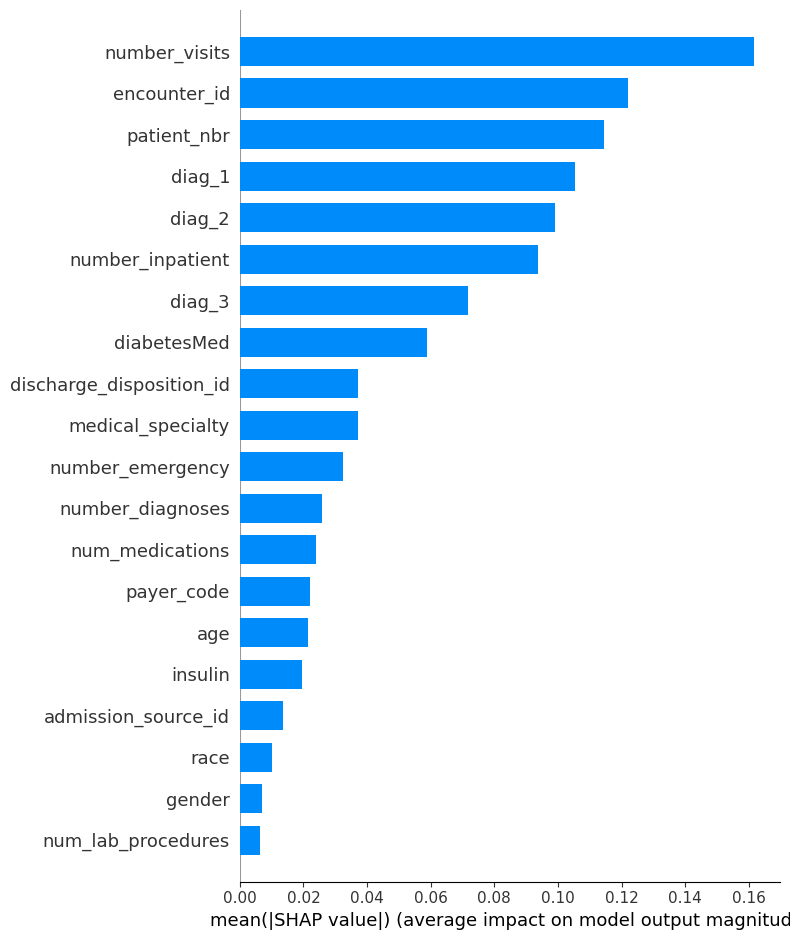

SHAP bar plot for: <30


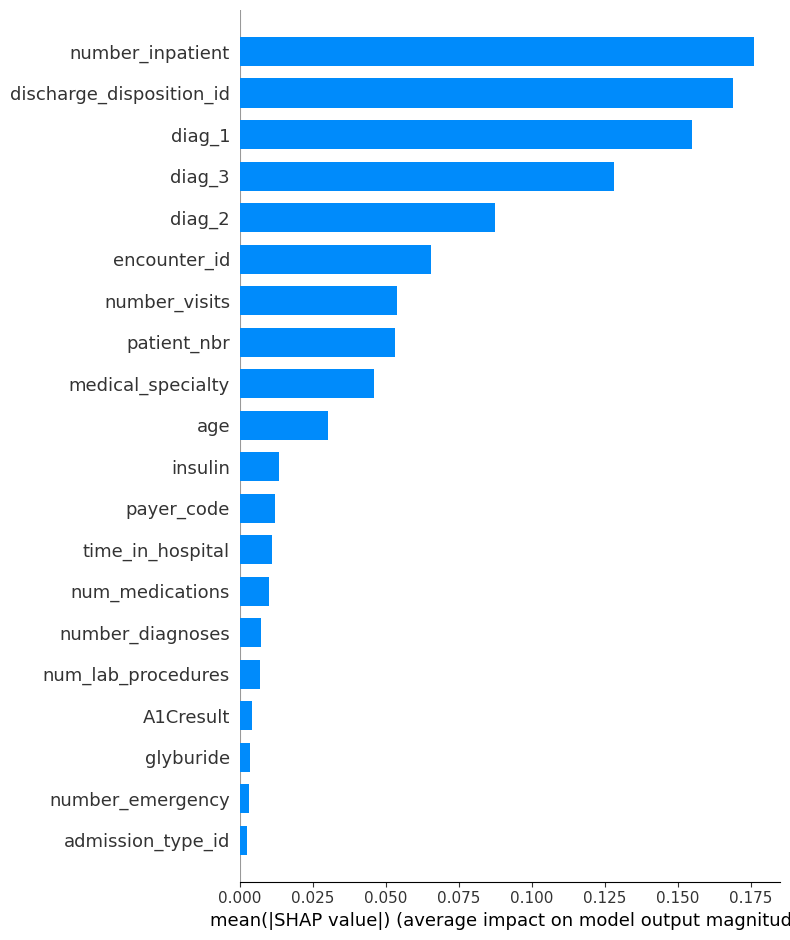

SHAP bar plot for: >30


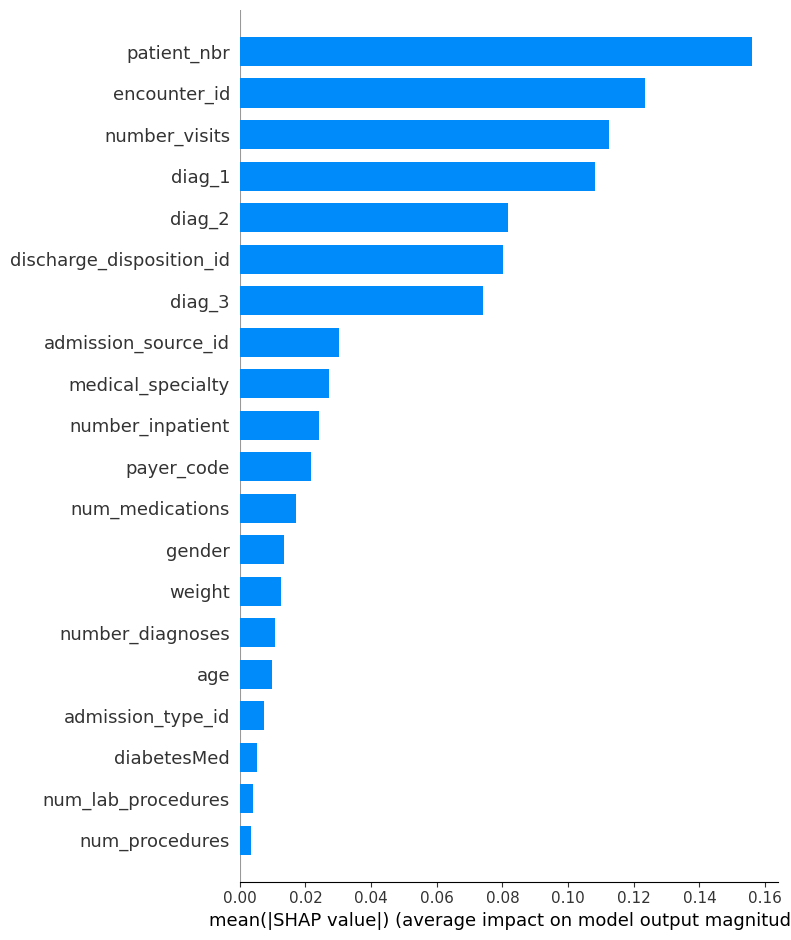

In [109]:
# Now we will use SHAP to explain the predictions of the final model trained with Optuna hyperparameters.

import shap

# We need to use a subset of the test set for SHAP explanations to keep the runtime manageable, especially since SHAP can be computationally expensive.
X_sample = X_test.sample(min(300, len(X_test)), random_state=42)

# We get booster because SHAP's TreeExplainer can directly use the booster object from XGBoost, which allows it to compute SHAP values efficiently.
booster = hyperopt_model.get_booster()

# Sometimes we stop our models early based on validation performance, which means that the best model is not necessarily the one with the maximum number of trees. 
# Hence we check if the model has the attribute best_iteration, which indicates the number of trees used in the best iteration during training. 
# If it exists, we will restrict our SHAP value calculations to only use those trees to match the behavior of sklearn's early stopping.

# To match sklearn behavior, restrict prediction to best_iteration + 1 trees.
best_iter = hyperopt_model.best_iteration if hasattr(hyperopt_model, "best_iteration") else None

# We create a DMatrix from the sample of the test set, which is the data structure that XGBoost uses for its predictions and SHAP value calculations.
dm_explain = xgb.DMatrix(X_sample, enable_categorical=True)

# We then call the predict method on the booster with pred_contribs=True to get the SHAP values (contributions) for each feature.
if best_iter is not None:
    shap_contribs = booster.predict(
        dm_explain,
        pred_contribs=True,
        strict_shape=True,
        iteration_range=(0, best_iter + 1)
    )
# If there is no best_iteration attribute, we just get the SHAP values using all the trees in the model.
else:
    shap_contribs = booster.predict(
        dm_explain,
        pred_contribs=True,
        strict_shape=True
    )


# feature_names is just the list of feature names from the original dataset, which we will use for interpreting the SHAP values.
feature_names = X_sample.columns.tolist()

# last column is bias term
shap_values = shap_contribs[:, :, :-1]
bias_values = shap_contribs[:, :, -1]

#print("SHAP values shape:", shap_values.shape)
#print("Bias values shape:", bias_values.shape)

classes = ["NO", "<30", ">30"]

# Now we print out the mean absolute SHAP value for each feature for each class, which gives us a sense of which features are most important for the model's predictions for each class.

for class_idx, class_name in enumerate(classes):
    mean_abs = np.abs(shap_values[:, class_idx, :]).mean(axis=0)
    
    # I will explain this is in person

    # Importance_df is used here because it is a convenient way to create a table of features and their corresponding mean absolute SHAP values, 
    # and then sort that table by the mean absolute SHAP values to easily identify the most important features for each class.
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"Top 10 for {class_name}:")
    display(importance_df.head(10))


# Bar plots for each class to visualize the mean absolute SHAP values for the features. 
# This will help us see which features are contributing the most to the model's predictions for each class in a more visual way.
for class_idx, class_name in enumerate(classes):
    
    print(f"SHAP bar plot for: {class_name}")
    
    shap.summary_plot(
        shap_values[:, class_idx, :],
        X_sample,
        plot_type="bar",
        show=True
    )